In [4]:
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
%matplotlib inline


In [5]:
import cv2 as cv

def load_image(filename='./Trump.jpg'):
    # Load the new image with a clearly visible face
    img = cv.imread(filename)

    top = 10 
    w_center = int(img.shape[1] / 2)
    img = img[top:top+500, w_center-250:w_center+250]
    return img

img = load_image()


In [3]:
# this function will filter an roi using a set of weights
def filter_and_plot(weights,roi):
    # these two lines are important as they ensure correct
    # computations!
    weights = weights.astype(float)
    roi = roi.astype(float)
    # this holds the end result
    filtered = np.zeros_like(roi)
    width = int((weights.shape[1]-1)/2)
    height = int((weights.shape[0]-1)/2)
    # do the filtering
    for i in range(height,roi.shape[1]-height):
        for j in range(width,roi.shape[0]-width):
            filtered[j,i]=np.sum(weights*roi[j-width:j+width+1,i-height:i+height+1])
    # plot the original, the filter, and the filtered image
    plt.figure(None, figsize=(14, 6))
    grid = plt.GridSpec(1, 7, wspace=0.4, hspace=0.3)
    plt.subplot(grid[0, 0:3])
    plt.imshow(roi,cmap='gray')
    plt.subplot(grid[0, 3])
    extent = (0, weights.shape[1], weights.shape[0], 0)
    plt.imshow(weights,cmap='gray',extent=extent)
    plt.axis('off')
    if width<5:
        for i in range(0,len(weights)):
            for j in range(0,len(weights)):
                if weights[i,j]>0.5*np.max(weights):
                    plt.text(j+0.1,i+0.6,'{0:.2f}'.format(weights[i,j]),color='black')
                else:
                    plt.text(j+0.1,i+0.6,'{0:.2f}'.format(weights[i,j]),color='white')
    plt.grid(True)
    plt.subplot(grid[0, 4:])
    plt.imshow(filtered,cmap='gray')
    plt.show()
    return(filtered)

In [1]:

def filter(image, kernel):
    image = image.astype(float)
    kernel = kernel.astype(float)
    
    filtered = np.zeros_like(image)
    width = int((kernel.shape[1]-1)/2)
    height = int((kernel.shape[0]-1)/2)

    for i in range(height, image.shape[1]-height):
        for j in range(width, image.shape[0]-width):
            filtered[j,i]=np.sum(kernel*image[j-width:j+width+1,i-height:i+height+1])

    return filtered

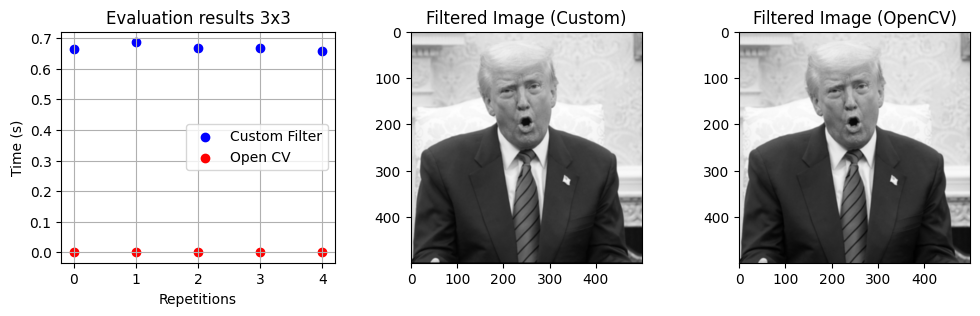

Size 3x3:
Custom Filter: Mean = 0.6686, Std = 0.0097
OpenCV Filter: Mean = 0.0002, Std = 0.0000


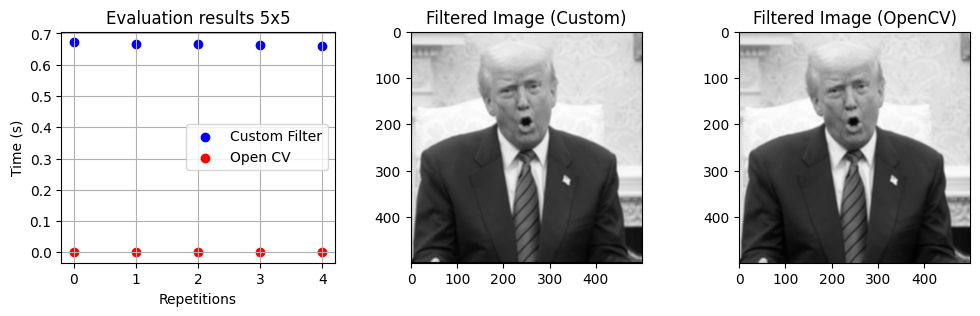

Size 5x5:
Custom Filter: Mean = 0.6656, Std = 0.0043
OpenCV Filter: Mean = 0.0004, Std = 0.0000


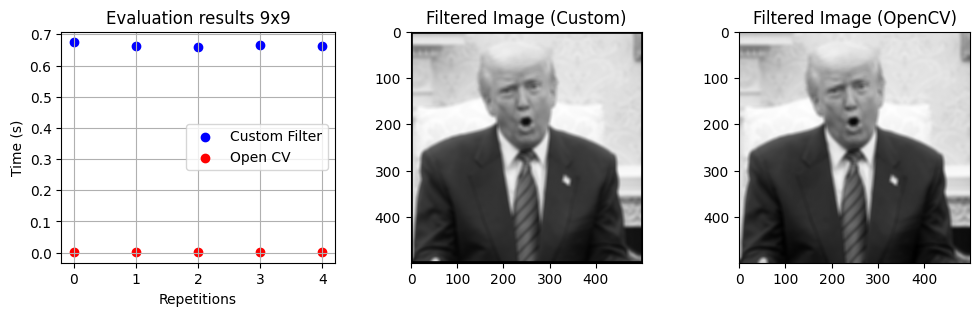

Size 9x9:
Custom Filter: Mean = 0.6647, Std = 0.0054
OpenCV Filter: Mean = 0.0013, Std = 0.0000


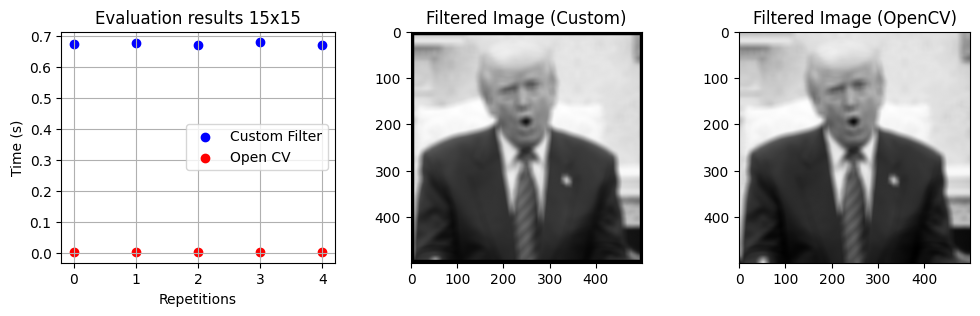

Size 15x15:
Custom Filter: Mean = 0.6740, Std = 0.0036
OpenCV Filter: Mean = 0.0022, Std = 0.0001


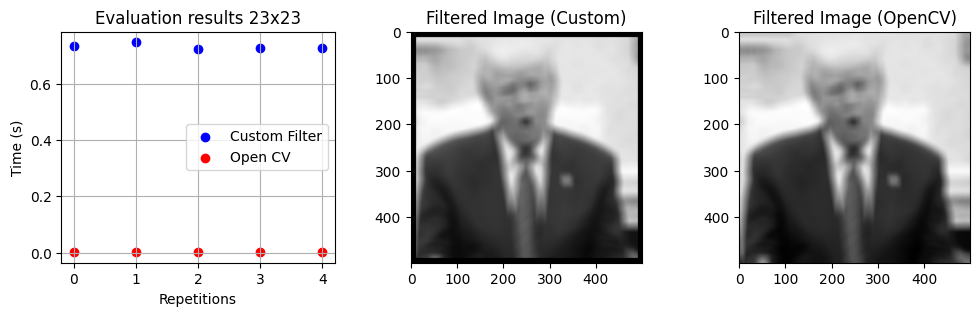

Size 23x23:
Custom Filter: Mean = 0.7308, Std = 0.0084
OpenCV Filter: Mean = 0.0022, Std = 0.0003


In [ ]:
import time
import numpy as np

def record(filter_func, reps=50):
    results = []
    for _ in range(reps):
        start = time.time()
        img = filter_func()
        end = time.time()
        results.append(end - start)

    return (results, img)


def plot_results(title, custom, cv):
    custom_result, custom_img = custom
    cv_result, cv_img = cv

    figure = plt.figure(figsize=(12, 3))

    ax = figure.add_subplot(131)
    ax.scatter(range(len(custom_result)), custom_result, label='Custom Filter', color='blue')
    ax.scatter(range(len(cv_result)), cv_result, label='Open CV', color='red')
    ax.set_xlabel('Repetitions')
    ax.set_ylabel('Time (s)')
    #ax.set_yscale('symlog')
    ax.legend()
    ax.grid(True)
    ax.set_title(title)

    ax = figure.add_subplot(132)
    ax.imshow(custom_img, cmap='gray')
    ax.set_title('Filtered Image (Custom)')

    ax = figure.add_subplot(133)
    ax.imshow(cv_img, cmap='gray')
    ax.set_title('Filtered Image (OpenCV)')
    plt.show()


def summary_results(index, custom, cv):
    custom_result, _ = custom
    cv_result, _ = cv
    
    custom_mean = np.mean(custom_result)
    cv_mean = np.mean(cv_result)

    custom_std = np.std(custom_result)
    cv_std = np.std(cv_result)

    print(f"Evaluation Results for Size {index}x{index}:")
    print(f"Custom Filter: Mean = {custom_mean:.4f}, Std = {custom_std:.4f}")
    print(f"OpenCV Filter: Mean = {cv_mean:.4f}, Std = {cv_std:.4f}")


def evaluate():
    '''
    Next, evaluate the timing of your filter function for a 500x500 pixel grey-scale 
    image of your choice against the OpenCV function cv2.filter2D for simple,
    normalized box-filters of size 3x3, 5x5, 9x9, 15x15, 23x23. A box-filter consists of only
    “1”s in all elements of the filter and is an averaging filter.
    '''
    img = load_image()
    img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    filter_sizes = [3, 5, 9, 15, 23]
    reps = 5

    for size in filter_sizes:
        box_filter = np.ones((size, size)) / (size * size)

        func = lambda: filter(img, box_filter)
        custom_result = record(func, reps=reps)

        func = lambda: cv.filter2D(img, -1, box_filter)
        cv_result = record(func, reps=reps)

        plot_results(f'Evaluation results {size}x{size}', custom_result, cv_result)
        summary_results(size, custom_result, cv_result)

evaluate()
